## Import libraries

In [77]:
#!pip install imblearn

In [78]:
import pandas as pd
import numpy as np

import glob
import os

import requests

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import zipfile

import xarray as xr

import folium
from folium.plugins import MarkerCluster

import pandas as pd
from geopy.geocoders import Nominatim

import geopandas as gpd
import cartopy.crs as ccrs

import imageio

from sklearn.neighbors import KDTree
from sklearn.neighbors import BallTree

from sklearn.preprocessing import RobustScaler

## Set parameters

In [79]:
decree_filename_base = 'arrete_'
decrees_folder_name = './../../data/raw/decrees'
communes_folder_name = './../../data/raw/opendatasoft'
weather_folder_name = './../../data/raw/weather/era5'
weather_ncfiles_folder_name = './../../data/raw/weather/era5/ncfiles2'
processed_data_folder_name = './../../data/processed'
output_data_folder_name = './../../data/processed/output'
decrees_filename = 'decrees.parquet'
decrees_locations_filename = 'decrees_locations.parquet'
communes_csv_filename = 'correspondance-code-insee-code-postal-202410.csv'
weather_filename = 'weather2.parquet'
weather_shema_filename = 'weather_shema2.csv'
weather_yearly_filename = 'weather2_yearly.parquet'
weather_yearly_shema_filename = 'weather_shema2_yearly.csv'
drought_filename = 'drought.parquet'
drought_shema_filename = 'drought_shema.csv'
drought_yearly_filename = 'drought_yearly.parquet'
drought_yearly_shema_filename = 'drought_yearly_shema.csv'
drought_commune_clean_filename = 'drought_commune_clean.parquet'
drought_commune_clean_shema_filename = 'drought_commune_clean_shema.csv'
drought_weather_filename = 'drought_weather.parquet'
drought_weather_shema_filename = 'drought_weather_shema.csv'
#weather_zip_file = "193fcd51a8958175843ecbbcaba057c8.zip"

## Load data

| Column    | Description                                      |
|-----------|--------------------------------------------------|
| date      | The date of the observation.                     |
| latitude  | The latitude coordinate of the observation point.|
| longitude | The longitude coordinate of the observation point.|
| number    | A unique identifier for the observation.         |
| expver    | Experiment version number.                       |
| u10       | 10-meter U-component of wind (eastward wind).    |
| v10       | 10-meter V-component of wind (northward wind).   |
| t2m       | 2-meter temperature (air temperature at 2 meters above the surface).|
| sp        | Surface pressure.                                |
| tp        | Total precipitation.                             |
| e         | Evaporation.                                     |
| sro       | Surface runoff.                                  |
| tcrw      | Total column water vapor.                        |
| stl1      | Soil temperature level 1.                        |
| stl2      | Soil temperature level 2.                        |
| slt       | Soil type.                                       |
| swvl1     | Volumetric soil water layer 1.                   |
| swvl2     | Volumetric soil water layer 2.                   |
| cvh       | High vegetation cover.                           |
| cvl       | Low vegetation cover.                            |
| tvh       | High vegetation type.                            |
| tvl       | Low vegetation type.                             |


## Import Data

In [80]:
# read the dataframe from parquet
import pandas as pd

df = pd.read_parquet(os.path.join(processed_data_folder_name, drought_weather_filename))




In [81]:
os.path.join(processed_data_folder_name, drought_weather_shema_filename)

'./../../data/processed/drought_weather_shema.csv'

In [82]:
# Load the schema (data types) from the file
schema = pd.read_csv(os.path.join(processed_data_folder_name, drought_weather_shema_filename), index_col=0).squeeze("columns")

In [83]:
# Apply the schema to the loaded dataframe
df = df.astype(schema.to_dict())

In [84]:
# Remove rows where applied_1 is equal to 0
df = df[df['applied_1'] != 0]

df_applied_ori = df.copy()

print(df)


      insee_1           nom_commune_1  latitude_1  longitude_1  year_1  \
9       10010            ARREMBECOURT   48.543296     4.606490    2000   
10      10011             ARRENTIERES   48.267992     4.739104    2000   
16      10018                   AUXON   48.092318     3.923462    2000   
23      10024                 AVREUIL   48.053139     3.998028    2000   
25      10026         BAILLY-LE-FRANC   48.522491     4.659134    2000   
...       ...                     ...         ...          ...     ...   
35990   95592             SERAINCOURT   49.042140     1.878670    2023   
35992   95598  SOISY-SOUS-MONTMORENCY   48.988408     2.300500    2023   
35994   95607                 TAVERNY   49.026732     2.221161    2023   
36002   95637                 VAUREAL   49.029507     2.024466    2023   
36011   95678           VILLIERS-ADAM   49.070289     2.239509    2023   

       year_count_1  year_duration_1  applied_1  decision_1 Code Postal_1  \
9               1.0              1

In [85]:
df.head()

,insee_1,nom_commune_1,latitude_1,longitude_1,year_1,year_count_1,year_duration_1,applied_1,decision_1,Code Postal_1,...,stl2_mean_2,slt_sum_2,slt_mean_2,swvl1_sum_2,swvl1_mean_2,swvl2_sum_2,swvl2_mean_2,latitude_rad_2,longitude_rad_2,distance_km
9,10010,ARREMBECOURT,48.543296,4.606490,2000,1.0,1.0,1,0,10330,...,11.691945,24.0,2.0,4.240410,0.353368,4.173016,0.347751,0.846485,0.078540,9.202538
10,10011,ARRENTIERES,48.267992,4.739104,2000,1.0,1.0,1,0,10200,...,11.360728,36.0,3.0,4.290780,0.357565,4.225537,0.352128,0.842121,0.082903,2.157139
16,10018,AUXON,48.092318,3.923462,2000,1.0,1.0,1,0,10130,...,11.610565,36.0,3.0,4.263848,0.355321,4.201031,0.350086,0.837758,0.069813,11.736634
23,10024,AVREUIL,48.053139,3.998028,2000,1.0,1.0,1,0,10130,...,11.610565,36.0,3.0,4.263848,0.355321,4.201031,0.350086,0.837758,0.069813,5.910659
25,10026,BAILLY-LE-FRANC,48.522491,4.659134,2000,1.0,1.0,1,0,10330,...,11.490936,24.0,2.0,4.288506,0.357376,4.234311,0.352859,0.846485,0.082903,7.145499


In [86]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'year_count_1', 'year_duration_1', 'applied_1', 'decision_1',
       'Code Postal_1', 'Département_1', 'Région_1', 'Code Département_1',
       'Code Région_1', 'latitude_rad_1', 'longitude_rad_1', 'latitude_2',
       'longitude_2', 'year_2', 't2m_z_sum_2', 't2m_z_mean_2', 'tp_z_sum_2',
       'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2', 'pev_z_sum_2', 'pev_z_mean_2',
       'stl1_z_sum_2', 'stl1_z_mean_2', 'stl2_z_sum_2', 'stl2_z_mean_2',
       'slt_z_sum_2', 'slt_z_mean_2', 'swvl1_z_sum_2', 'swvl1_z_mean_2',
       'swvl2_z_sum_2', 'swvl2_z_mean_2', 't2m_sum_2', 't2m_mean_2',
       'tp_sum_2', 'tp_mean_2', 'e_sum_2', 'e_mean_2', 'pev_sum_2',
       'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2', 'stl2_sum_2', 'stl2_mean_2',
       'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2', 'swvl1_mean_2', 'swvl2_sum_2',
       'swvl2_mean_2', 'latitude_rad_2', 'longitude_rad_2', 'distance_km'],
      dtype='object')

In [87]:
df.dtypes

insee_1                object
nom_commune_1          object
latitude_1            float64
longitude_1           float64
year_1                  int64
year_count_1          float64
year_duration_1       float64
applied_1               int64
decision_1              int64
Code Postal_1          object
Département_1          object
Région_1               object
Code Département_1     object
Code Région_1           int64
latitude_rad_1        float64
longitude_rad_1       float64
latitude_2            float64
longitude_2           float64
year_2                  int32
t2m_z_sum_2           float64
t2m_z_mean_2          float64
tp_z_sum_2            float64
tp_z_mean_2           float64
e_z_sum_2             float64
e_z_mean_2            float64
pev_z_sum_2           float64
pev_z_mean_2          float64
stl1_z_sum_2          float64
stl1_z_mean_2         float64
stl2_z_sum_2          float64
stl2_z_mean_2         float64
slt_z_sum_2           float64
slt_z_mean_2          float64
swvl1_z_su

In [88]:
df.select_dtypes(include=['object']).describe()

,insee_1,nom_commune_1,Code Postal_1,Département_1,Région_1,Code Département_1
count,387086,387086,387086,387086,387086,387086
unique,15901,15077,4136,94,21,94
top,47032,SAINTE-RADEGONDE,32300,['DORDOGNE'],['MIDI-PYRENEES'],24
freq,37,176,748,12752,48048,12752


In [89]:
df.select_dtypes(include=['int32', 'int64']).describe()

,year_1,applied_1,decision_1,Code Région_1,year_2
count,387086.000000,387086.0,387086.000000,387086.000000,387086.000000
mean,2011.491297,1.0,0.085531,53.217494,2011.491297
std,6.895176,0.0,0.279671,25.026886,6.895176
min,2000.000000,1.0,0.000000,11.000000,2000.000000
25%,2006.000000,1.0,0.000000,26.000000,2006.000000
50%,2011.000000,1.0,0.000000,54.000000,2011.000000
75%,2017.000000,1.0,0.000000,73.000000,2017.000000
max,2023.000000,1.0,1.000000,93.000000,2023.000000


In [90]:
df.select_dtypes(include=['float32', 'float64']).describe()

,latitude_1,longitude_1,year_count_1,year_duration_1,latitude_rad_1,longitude_rad_1,latitude_2,longitude_2,t2m_z_sum_2,t2m_z_mean_2,...,stl2_mean_2,slt_sum_2,slt_mean_2,swvl1_sum_2,swvl1_mean_2,swvl2_sum_2,swvl2_mean_2,latitude_rad_2,longitude_rad_2,distance_km
count,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,...,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000,387086.000000
mean,46.380308,2.643289,1.019593,1.024571,0.809489,0.046134,46.380635,2.643289,4.617532,0.384794,...,12.310477,29.391422,2.449285,3.805463,0.317122,3.709279,0.309107,0.809495,0.046134,9.059988
std,2.058532,2.353549,0.267611,0.333465,0.035928,0.041077,2.059565,2.354043,4.223966,0.351997,...,1.599689,7.411154,0.617596,0.494677,0.041223,0.515813,0.042984,0.035946,0.041086,3.547651
min,42.473962,-4.587631,1.000000,1.000000,0.741310,-0.080069,42.500000,-4.500000,-8.730521,-0.727543,...,3.081716,0.000000,0.000000,-0.000040,-0.000003,-0.000050,-0.000004,0.741765,-0.078540,0.134907
25%,44.511405,0.684349,1.000000,1.000000,0.776871,0.011944,44.500000,0.750000,1.424884,0.118740,...,11.225108,24.000000,2.000000,3.628061,0.302338,3.483410,0.290284,0.776672,0.013090,6.496673
50%,46.532541,2.375800,1.000000,1.000000,0.812146,0.041466,46.500000,2.500000,5.095571,0.424631,...,12.208954,24.000000,2.000000,3.862311,0.321859,3.764148,0.313679,0.811578,0.043633,9.179796
75%,48.048391,4.717058,1.000000,1.000000,0.838603,0.082328,48.000000,4.750000,7.979097,0.664925,...,13.385081,36.000000,3.000000,4.083582,0.340299,4.016697,0.334725,0.837758,0.082903,11.842469
max,51.063772,8.000078,13.000000,13.000000,0.891231,0.139628,51.000000,8.000000,17.793317,1.482776,...,18.915518,48.000000,4.000000,5.718729,0.476561,5.756094,0.479674,0.890118,0.139626,17.054464


In [91]:
def plot_distance_boxplot(df):
    fig = px.box(df, y='distance_km', title='Boxplot of Distance (km)', labels={'distance_km': 'Distance (km)'})
    fig.show()

# Example usage for the plot:
# plot_distance_boxplot(df)

In [92]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'year_count_1', 'year_duration_1', 'applied_1', 'decision_1',
       'Code Postal_1', 'Département_1', 'Région_1', 'Code Département_1',
       'Code Région_1', 'latitude_rad_1', 'longitude_rad_1', 'latitude_2',
       'longitude_2', 'year_2', 't2m_z_sum_2', 't2m_z_mean_2', 'tp_z_sum_2',
       'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2', 'pev_z_sum_2', 'pev_z_mean_2',
       'stl1_z_sum_2', 'stl1_z_mean_2', 'stl2_z_sum_2', 'stl2_z_mean_2',
       'slt_z_sum_2', 'slt_z_mean_2', 'swvl1_z_sum_2', 'swvl1_z_mean_2',
       'swvl2_z_sum_2', 'swvl2_z_mean_2', 't2m_sum_2', 't2m_mean_2',
       'tp_sum_2', 'tp_mean_2', 'e_sum_2', 'e_mean_2', 'pev_sum_2',
       'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2', 'stl2_sum_2', 'stl2_mean_2',
       'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2', 'swvl1_mean_2', 'swvl2_sum_2',
       'swvl2_mean_2', 'latitude_rad_2', 'longitude_rad_2', 'distance_km'],
      dtype='object')

In [93]:
z_columns = [col for col in df.columns if '_z_' in col]
z_columns

['t2m_z_sum_2',
 't2m_z_mean_2',
 'tp_z_sum_2',
 'tp_z_mean_2',
 'e_z_sum_2',
 'e_z_mean_2',
 'pev_z_sum_2',
 'pev_z_mean_2',
 'stl1_z_sum_2',
 'stl1_z_mean_2',
 'stl2_z_sum_2',
 'stl2_z_mean_2',
 'slt_z_sum_2',
 'slt_z_mean_2',
 'swvl1_z_sum_2',
 'swvl1_z_mean_2',
 'swvl2_z_sum_2',
 'swvl2_z_mean_2']

In [94]:
df['decision_1'].describe()

count    387086.000000
mean          0.085531
std           0.279671
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: decision_1, dtype: float64

In [95]:
df['decision_1'].value_counts()

decision_1
0    353978
1     33108
Name: count, dtype: int64

In [96]:
# Select columns that contain '_sum' and '_mean' but not '_z'
selected_columns = [col for col in df.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]

# Create a new DataFrame with the selected columns
df_selected = df[selected_columns]

print(df_selected.columns)

Index(['t2m_sum_2', 't2m_mean_2', 'tp_sum_2', 'tp_mean_2', 'e_sum_2',
       'e_mean_2', 'pev_sum_2', 'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2',
       'stl2_sum_2', 'stl2_mean_2', 'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2',
       'swvl1_mean_2', 'swvl2_sum_2', 'swvl2_mean_2'],
      dtype='object')


In [97]:
df['year_1'].describe()

count    387086.000000
mean       2011.491297
std           6.895176
min        2000.000000
25%        2006.000000
50%        2011.000000
75%        2017.000000
max        2023.000000
Name: year_1, dtype: float64

In [98]:
df = df[df['year_1'] <= 2020]

In [99]:
df['year_count_1'].describe()

count    338973.000000
mean          1.020291
std           0.271794
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          13.000000
Name: year_count_1, dtype: float64

In [100]:
df = df[df['year_count_1'] == 1]

## Models

### Logistic Regression

#### simple

Checking for missing values...

Series([], dtype: int64)


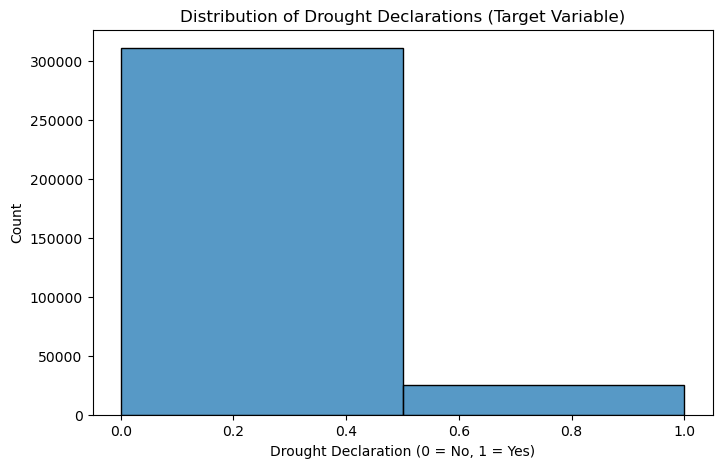

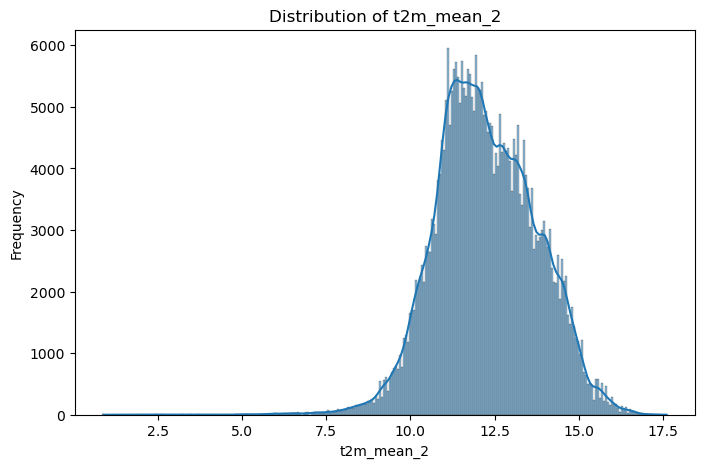

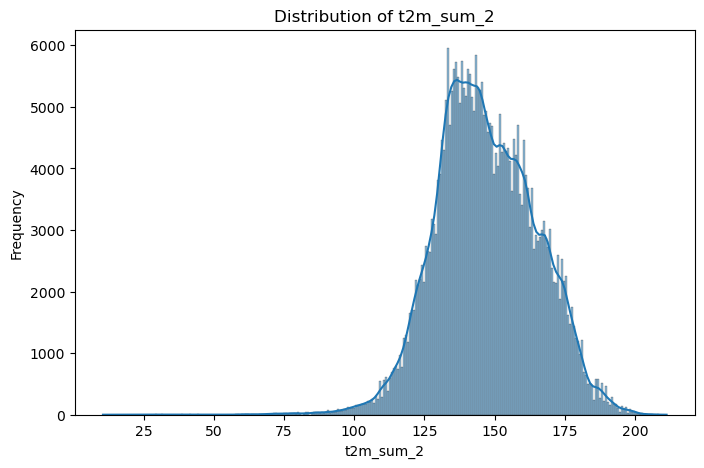

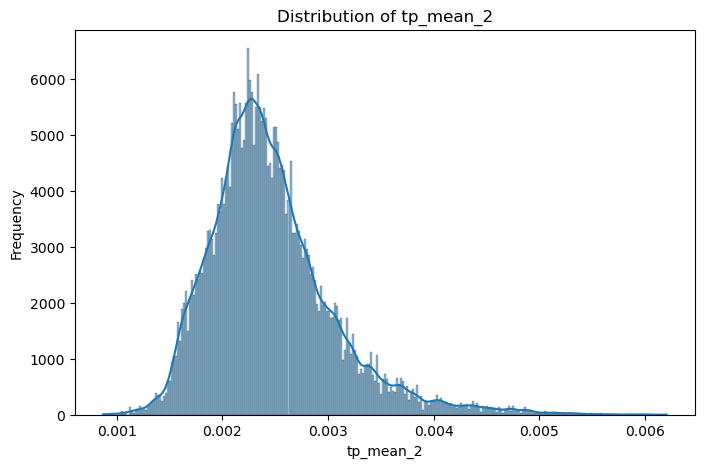

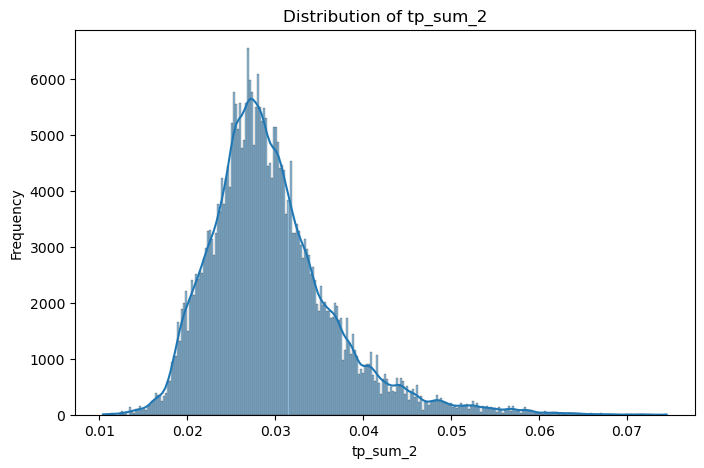

          latitude_1    longitude_1         year_1  year_count_1  \
count  335917.000000  335917.000000  335917.000000      335917.0   
mean       46.390695       2.647832    2010.010258           1.0   
std         2.056190       2.359301       6.024911           0.0   
min        42.473962      -4.587631    2000.000000           1.0   
25%        44.537084       0.669752    2005.000000           1.0   
50%        46.540725       2.385745    2010.000000           1.0   
75%        48.054810       4.729963    2015.000000           1.0   
max        51.063772       8.000078    2020.000000           1.0   

       year_duration_1  applied_1     decision_1  Code Région_1  \
count    335917.000000   335917.0  335917.000000  335917.000000   
mean          1.000777        1.0       0.074176      53.163531   
std           0.030806        0.0       0.262058      25.031865   
min           1.000000        1.0       0.000000      11.000000   
25%           1.000000        1.0       0.000000    

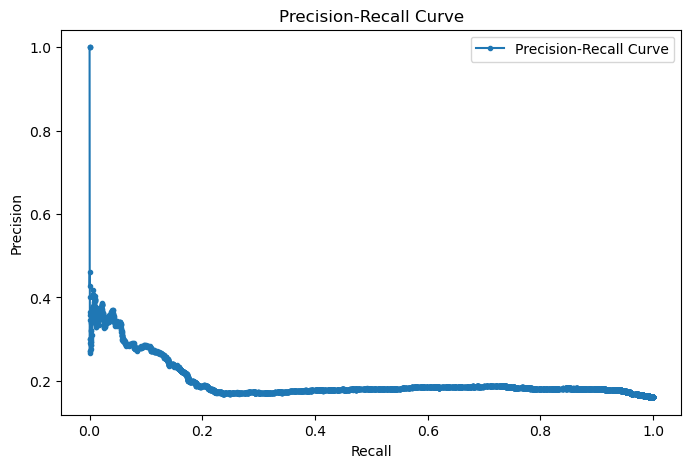

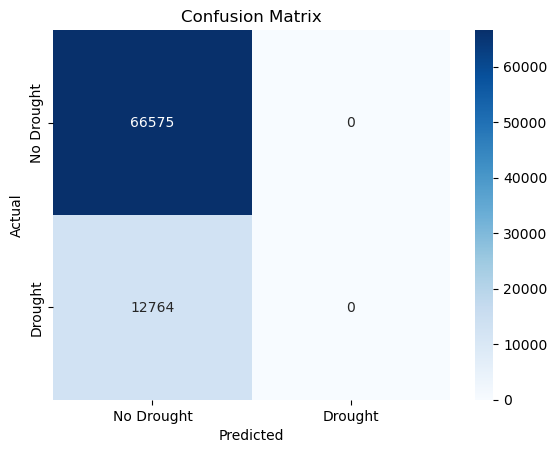

Summary Performance for the Linear Regression Model:
Recall: 0.0000
F1 Score: 0.0000
ROC AUC Score: 0.5672
Classification Report:
              precision    recall  f1-score   support

  No Drought       0.84      1.00      0.91     66575
     Drought       1.00      0.00      0.00     12764

    accuracy                           0.84     79339
   macro avg       0.92      0.50      0.46     79339
weighted avg       0.87      0.84      0.77     79339



In [101]:
# Predicting Drought Emergency Declarations for French Communes

# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.linear_model import LinearRegression
import datetime
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset (assuming CSV file)
# df = pd.read_csv('french_communes_weather.csv')

# 1. Data Preprocessing
## Check for Missing Values and Remove if Found
print("Checking for missing values...\n")
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])
df.dropna(inplace=True)

# 2. Exploratory Data Analysis (EDA)
## Understand the Target Variable Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['decision_1'], kde=False, bins=2)
plt.title('Distribution of Drought Declarations (Target Variable)')
plt.xlabel('Drought Declaration (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## Exploratory Visualizations
# Plot the yearly temperature and precipitation trends to understand data behavior
temp_cols = ['t2m_mean_2', 't2m_sum_2']
precip_cols = ['tp_mean_2', 'tp_sum_2']

for col in temp_cols + precip_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Descriptive Statistics
print(df.describe())

# 3. Data Splitting and Temporal Awareness
## Split Data for Temporal Prediction
df = df.sort_values(by='year_1')
train = df[df['year_1'] < df['year_1'].quantile(0.8)]
test = df[df['year_1'] >= df['year_1'].quantile(0.8)]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

# Split into Features and Target Variables
##weather_features = [col for col in df.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]
weather_features=temp_cols+precip_cols
X_train = train[weather_features]
y_train = train['decision_1']
X_test = test[weather_features]
y_test = test['decision_1']

# 4. Model Building Using Simple Linear Regression
# Initialize the Linear Regression Model
model_lr = LinearRegression()

# Train the Model
model_lr.fit(X_train, y_train)

# Make Predictions
y_pred = model_lr.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

# Calculate Metrics
recall = recall_score(y_test, y_pred_binary, pos_label=1)
f1 = f1_score(y_test, y_pred_binary, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred, average='weighted')

# Precision-Recall Curve (Focusing on Recall for Drought)
precision, recall_curve, thresholds = precision_recall_curve(y_test, y_pred)
plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision, marker='.', label='Precision-Recall Curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Drought', 'Drought'], yticklabels=['No Drought', 'Drought'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Summary Performance for the Linear Regression Model
print("Summary Performance for the Linear Regression Model:")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['No Drought', 'Drought'], zero_division=1))

# End of Notebook


### Change threshold

Checking for missing values...

Series([], dtype: int64)


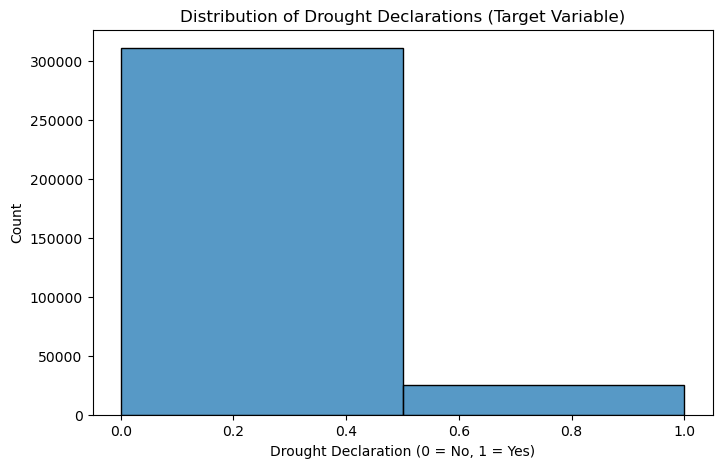

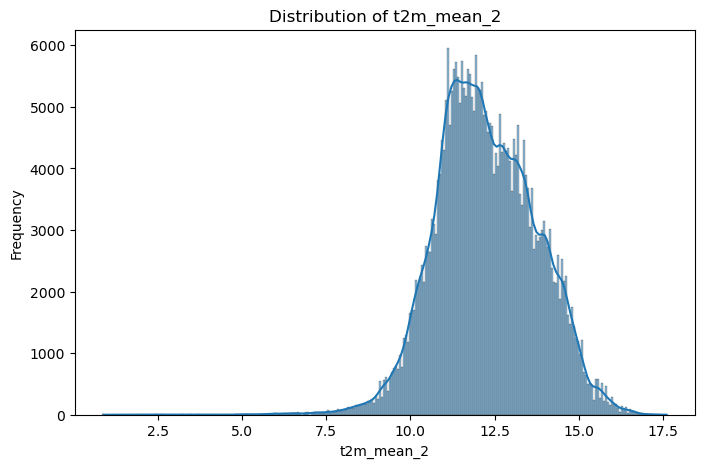

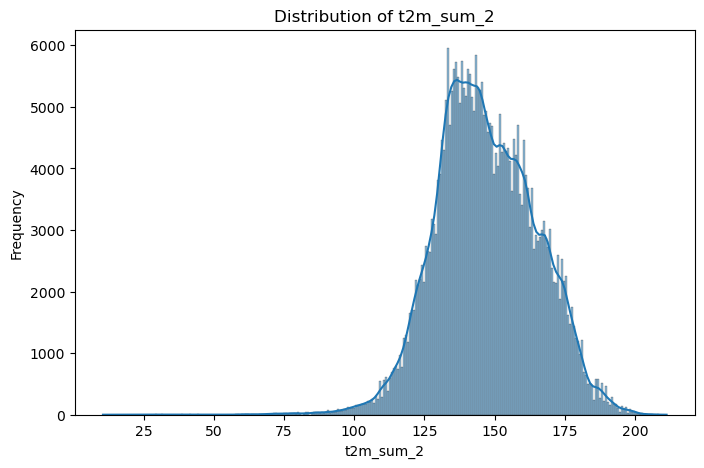

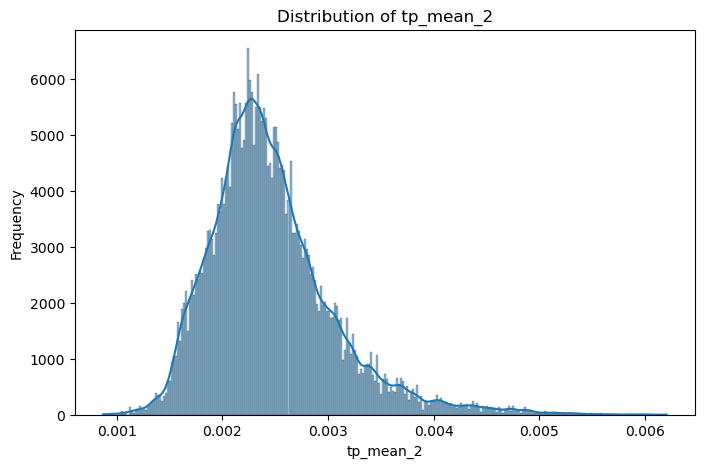

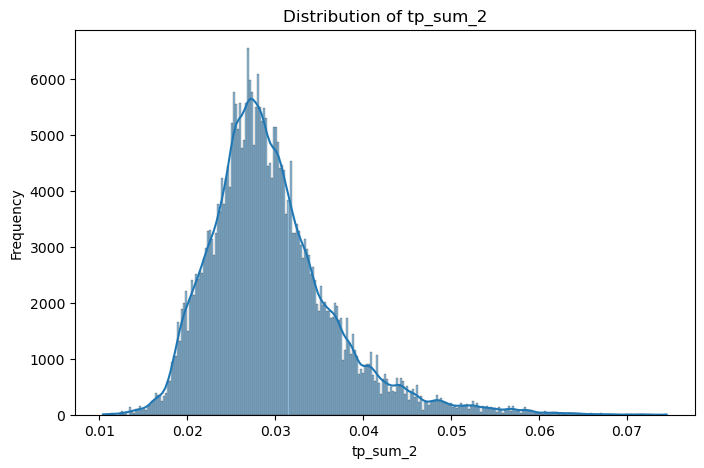

          latitude_1    longitude_1         year_1  year_count_1  \
count  335917.000000  335917.000000  335917.000000      335917.0   
mean       46.390695       2.647832    2010.010258           1.0   
std         2.056190       2.359301       6.024911           0.0   
min        42.473962      -4.587631    2000.000000           1.0   
25%        44.537084       0.669752    2005.000000           1.0   
50%        46.540725       2.385745    2010.000000           1.0   
75%        48.054810       4.729963    2015.000000           1.0   
max        51.063772       8.000078    2020.000000           1.0   

       year_duration_1  applied_1     decision_1  Code Région_1  \
count    335917.000000   335917.0  335917.000000  335917.000000   
mean          1.000777        1.0       0.074176      53.163531   
std           0.030806        0.0       0.262058      25.031865   
min           1.000000        1.0       0.000000      11.000000   
25%           1.000000        1.0       0.000000    

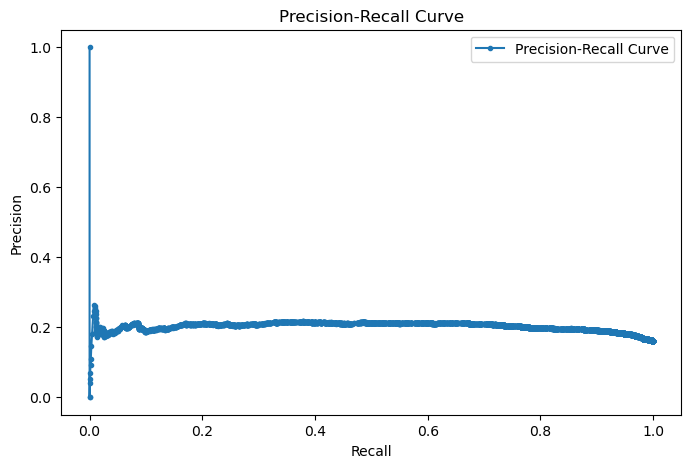

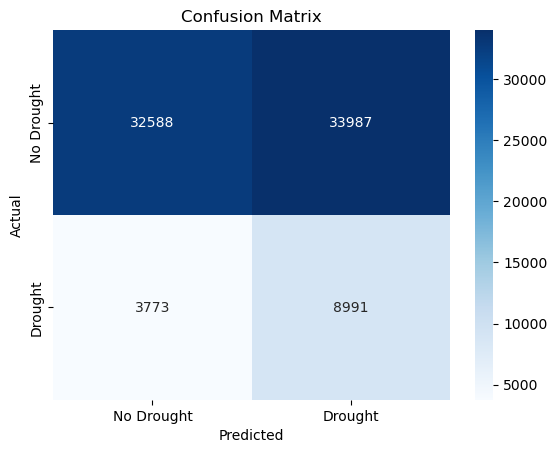

Summary Performance for the Linear Regression Model (Threshold = 0.3):
Recall: 0.7044
F1 Score: 0.3226
ROC AUC Score: 0.6166
Classification Report:
              precision    recall  f1-score   support

  No Drought       0.90      0.49      0.63     66575
     Drought       0.21      0.70      0.32     12764

    accuracy                           0.52     79339
   macro avg       0.55      0.60      0.48     79339
weighted avg       0.79      0.52      0.58     79339



In [102]:
# Predicting Drought Emergency Declarations for French Communes

# Importing Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import recall_score, precision_recall_curve, f1_score, confusion_matrix, roc_auc_score, classification_report
from sklearn.linear_model import LinearRegression
import datetime
import warnings
warnings.filterwarnings("ignore")

# Load the Dataset (assuming CSV file)
# df = pd.read_csv('french_communes_weather.csv')

# 1. Data Preprocessing
## Check for Missing Values and Remove if Found
print("Checking for missing values...\n")
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])
df.dropna(inplace=True)

# 2. Exploratory Data Analysis (EDA)
## Understand the Target Variable Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['decision_1'], kde=False, bins=2)
plt.title('Distribution of Drought Declarations (Target Variable)')
plt.xlabel('Drought Declaration (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

## Exploratory Visualizations
# Plot the yearly temperature and precipitation trends to understand data behavior
temp_cols = ['t2m_mean_2', 't2m_sum_2']
precip_cols = ['tp_mean_2', 'tp_sum_2']

for col in temp_cols + precip_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## Descriptive Statistics
print(df.describe())

# 3. Data Splitting and Temporal Awareness
## Split Data for Temporal Prediction
df = df.sort_values(by='year_1')
train = df[df['year_1'] < df['year_1'].quantile(0.8)]
test = df[df['year_1'] >= df['year_1'].quantile(0.8)]

print("Training set shape:", train.shape)
print("Testing set shape:", test.shape)

# Split into Features and Target Variables
weather_features = [col for col in df.columns if ('_sum' in col or '_mean' in col) and '_z' not in col]
X_train = train[weather_features]
y_train = train['decision_1']
X_test = test[weather_features]
y_test = test['decision_1']

# 4. Model Building Using Simple Linear Regression
# Initialize the Linear Regression Model
model_lr = LinearRegression()

# Train the Model
model_lr.fit(X_train, y_train)

# Make Predictions
y_pred = model_lr.predict(X_test)
threshold = 0.1  # Adjusted threshold to improve recall for drought cases
y_pred_binary = (y_pred > threshold).astype(int)

# Calculate Metrics
recall = recall_score(y_test, y_pred_binary, pos_label=1)
f1 = f1_score(y_test, y_pred_binary, pos_label=1)
roc_auc = roc_auc_score(y_test, y_pred, average='weighted')

# Precision-Recall Curve (Focusing on Recall for Drought)
precision, recall_curve, thresholds = precision_recall_curve(y_test, y_pred)
plt.figure(figsize=(8, 5))
plt.plot(recall_curve, precision, marker='.', label='Precision-Recall Curve')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

# Confusion Matrix Visualization
conf_matrix = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Drought', 'Drought'], yticklabels=['No Drought', 'Drought'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Summary Performance for the Linear Regression Model
print("Summary Performance for the Linear Regression Model (Threshold = 0.3):")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_binary, target_names=['No Drought', 'Drought'], zero_division=1))

# End of Notebook


#### Precision and Classification Report:

- **No Drought** (Class 0):
  - **Precision** is 0.89, which means when the model predicts No Drought, it is correct in 89% of the cases.
  - **Recall** dropped to 0.49, indicating that only about 49% of the true No Drought cases are being correctly predicted, which is likely due to the lower threshold allowing more predictions of Drought.
- **Drought** (Class 1):
  - **Precision** is 0.21, meaning the model often incorrectly predicts Drought when there is no actual drought.
  - **Recall** has greatly improved to 0.69. This means the model has a much better rate of capturing actual drought cases, even at the cost of misclassifying some No Drought instances as Drought.
  - **Accuracy** dropped to 0.53, which suggests that overall correct predictions decreased, but this is acceptable in this context since the goal is to capture as many true droughts as possible, even at the cost of more false positives.

In [76]:
df.columns

Index(['insee_1', 'nom_commune_1', 'latitude_1', 'longitude_1', 'year_1',
       'applied_1', 'decision_1', 'Code Postal_1', 'Département_1', 'Région_1',
       'Code Département_1', 'Code Région_1', 'latitude_rad_1',
       'longitude_rad_1', 'latitude_2', 'longitude_2', 'year_2', 't2m_z_sum_2',
       't2m_z_mean_2', 'tp_z_sum_2', 'tp_z_mean_2', 'e_z_sum_2', 'e_z_mean_2',
       'pev_z_sum_2', 'pev_z_mean_2', 'stl1_z_sum_2', 'stl1_z_mean_2',
       'stl2_z_sum_2', 'stl2_z_mean_2', 'slt_z_sum_2', 'slt_z_mean_2',
       'swvl1_z_sum_2', 'swvl1_z_mean_2', 'swvl2_z_sum_2', 'swvl2_z_mean_2',
       't2m_sum_2', 't2m_mean_2', 'tp_sum_2', 'tp_mean_2', 'e_sum_2',
       'e_mean_2', 'pev_sum_2', 'pev_mean_2', 'stl1_sum_2', 'stl1_mean_2',
       'stl2_sum_2', 'stl2_mean_2', 'slt_sum_2', 'slt_mean_2', 'swvl1_sum_2',
       'swvl1_mean_2', 'swvl2_sum_2', 'swvl2_mean_2', 'latitude_rad_2',
       'longitude_rad_2', 'distance_km'],
      dtype='object')